# Classification of Handwritten Digits Dataset using Neural Networks

In [ ]:
from tensorflow.keras  import layers,models,callbacks
import tensorflow as tf
import matplotlib.pyplot as plt
import keras

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training dataset shape:", X_train.shape, y_train.shape)
print("Testing dataset shape:",X_test.shape, y_test.shape)
print("Image shape:", X_train[0].shape)

Training dataset shape: (60000, 28, 28) (60000,)
Testing dataset shape: (10000, 28, 28) (10000,)
Image shape: (28, 28)


In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
X_train_flat= X_train.reshape(len(X_train),28*28)
X_test_flat= X_test.reshape(len(X_test),28*28)

In [ ]:
print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


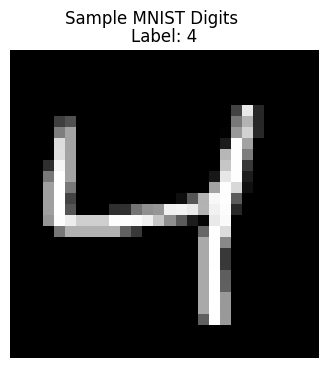

In [ ]:
plt.figure(figsize=(10,4))
plt.imshow(X_train[2], cmap="gray")
plt.title(f"Label: {y_train[2]}")
plt.axis(False)
plt.suptitle("Sample MNIST Digits")
plt.show()

In [ ]:
import time
import pandas as pd

def build_model(num_layers, neurons, lr):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(num_layers):
        model.add(layers.Dense(neurons, activation="relu"))

    model.add(layers.Dense(10, activation="softmax"))
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
best_val_acc = 0
best_model = None
best_params = None


In [ ]:
layer_options = [3, 5, 7]
neuron_options = [8, 16, 32, 64]
lr_options = [0.001, 0.01, 0.0001]
results = []

for num_layers in layer_options:
    for neurons in neuron_options:
        for lr in lr_options:

            print(f"\nTraining: Layers={num_layers}, Neurons={neurons}, LR={lr}")

            model = build_model(num_layers, neurons, lr)

            start_time = time.time()

            history = model.fit(
                X_train_flat, y_train,
                validation_data=(X_test_flat, y_test),
                epochs=10,
                batch_size=128,
                verbose=0
            )

            end_time = time.time()
            train_time = end_time - start_time

            train_acc = history.history["accuracy"][-1]
            val_acc = history.history["val_accuracy"][-1]

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = (num_layers, neurons, lr)

                model.save("/content/drive/MyDrive/models/best_model.h5")
                print("Best model saved")

            results.append({
                "Layers": num_layers,
                "Neurons": neurons,
                "Learning Rate": lr,
                "Train Accuracy": round(train_acc, 4),
                "Val Accuracy": round(val_acc, 4),
                "Training Time (s)": round(train_time, 2)
            })



Training: Layers=3, Neurons=8, LR=0.001


Best model saved

Training: Layers=3, Neurons=8, LR=0.01

Training: Layers=3, Neurons=8, LR=0.0001

Training: Layers=3, Neurons=16, LR=0.001


Best model saved

Training: Layers=3, Neurons=16, LR=0.01

Training: Layers=3, Neurons=16, LR=0.0001

Training: Layers=3, Neurons=32, LR=0.001


Best model saved

Training: Layers=3, Neurons=32, LR=0.01

Training: Layers=3, Neurons=32, LR=0.0001

Training: Layers=3, Neurons=64, LR=0.001


Best model saved

Training: Layers=3, Neurons=64, LR=0.01

Training: Layers=3, Neurons=64, LR=0.0001

Training: Layers=5, Neurons=8, LR=0.001

Training: Layers=5, Neurons=8, LR=0.01

Training: Layers=5, Neurons=8, LR=0.0001

Training: Layers=5, Neurons=16, LR=0.001

Training: Layers=5, Neurons=16, LR=0.01

Training: Layers=5, Neurons=16, LR=0.0001

Training: Layers=5, Neurons=32, LR=0.001

Training: Layers=5, Neurons=32, LR=0.01

Training: Layers=5, Neurons=32, LR=0.0001

Training: Layers=5, Neurons=64, LR=0.001

Training: Layers=5, Neurons=64, LR=0.01

Training: Layers=5, Neurons=64, LR=0.0001

Training: Layers=7, Neurons=8, LR=0.001

Training: Layers=7, Neurons=8, LR=0.01

Training: Layers=7, Neurons=8, LR=0.0001

Training: Layers=7, Neurons=16, LR=0.001

Training: Layers=7, Neurons=16, LR=0.01

Training: Layers=7, Neurons=16, LR=0.0001

Training: Layers=7, Neurons=32, LR=0.001

Training: Layers=7, Neurons=32, LR=0.01

Training: Layers=7, Neurons=32, LR=0.0001

Training: Layers=7, Ne

In [ ]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Val Accuracy", ascending=False, inplace=True)
df_results.head(40)

,Layers,Neurons,Learning Rate,Train Accuracy,Val Accuracy,Training Time (s)
9,3,64,0.0010,0.9889,0.9732,8.64
21,5,64,0.0010,0.9873,0.9722,9.67
33,7,64,0.0010,0.9851,0.9711,10.69
22,5,64,0.0100,0.9775,0.9709,9.70
10,3,64,0.0100,0.9811,0.9675,8.77
6,3,32,0.0010,0.9748,0.9649,7.72
34,7,64,0.0100,0.9654,0.9641,10.63
30,7,32,0.0010,0.9736,0.9624,9.26
18,5,32,0.0010,0.9764,0.9621,8.85
19,5,32,0.0100,0.9672,0.9588,8.46


In [ ]:
print("\nBest Model Summary")
print("Best Validation Accuracy:", best_val_acc)
print("Best Parameters: Layers=%d, Neurons=%d, LR=%f" % best_params)



Best Model Summary
Best Validation Accuracy: 0.9732000231742859
Best Parameters: Layers=3, Neurons=64, LR=0.001000
